# Bellabeat Case Study

## Google Data Analytics Capstone Project

Author: Timothy John
Date: 29/06/2026
Tools:
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Introduction
Bellabeat is a wellness technology company that develops wearable devices for women and seeks to understand trends in smart device usage. This case study analyses Fitbit user data to provide an analysis of how consumers use their smart devices, based on data from 30 Fitbit users over 31 days of use, and to identify behavioural trends that can inform Bellabeat's marketing strategy.
The goal of this report is 

### Business Task
Analyse smart device usage data to discover user behaviour trends and recommend marketing strategies for Bellabeat.

### Stakeholders
- Urška Sršen
- Sando Mur
- Marketing Analytics Team
- Executive Team

### Business Questions
1. What trends exist in smart device usage?
2. How do these trends apply to Bellabeat customers?
3. How can Bellabeat use these insights for marketing?

## Data Preparation

#### Data Source
The source of data was obtained from the FitBit Fitness Tracker Dataset (https://www.kaggle.com/datasets/arashnic/fitbit) Kaggle repository.
This dataset is licensed under the CCO: Public domain, which allows anyone to copy, modify, share and use it without permission. I shall like to note that the dataset contains Fitbit data from 30 consenting users, which limits how well the findings can be generalised.
Also, worthy of mention is the missing demographic information, such as age, gender of the sample data size in use. Since Bellabeat focuses on women's health, this would likely limit the ability to identify insights specific to its target audience. This omission might be due to privacy considerations.
##### Some data files
- dailyActivity.csv 
- sleepDay.csv 
- weightLog.csv 
- heartRate.csv 
- hourlyCalories.csv 
- hourlySteps.csv 
- hourlyIntensity.csv 
- etc.

Each file contains one aspect of user activity

### Data Credibility (ROCCC)
| Criterion     | Evaluation     |
| ------------- | -------------- |
| Reliable      | Moderate       |
| Original      | No             |
| Comprehensive | Limited        |
| Current       | No (2016 data) |
| Cited         | Yes            |


## Data Process

Libraries used for this analysis have been imported as shown below

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data files used from the raw data (https://www.kaggle.com/datasets/arashnic/fitbit): Daily Activity, Sleep Day, Daily Calories, Daily steps, Daily intensity, and Weight log. Upon loading them into Jupyter Notebook as dataframes, a new name was given to them for easy reference when writing code.
Datasets were unzipped and imported into Jupyter Notebook for analysis.

In [3]:

daily_activity = pd.read_csv('Downloads/Data Analysis Case Study/fitbit_archive/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv') 
sleep = pd.read_csv('Downloads/Data Analysis Case Study/fitbit_archive/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv')
calories = pd.read_csv('Downloads/Data Analysis Case Study/fitbit_archive/Fitabase Data 4.12.16-5.12.16/dailyCalories_merged.csv')
steps = pd.read_csv('Downloads/Data Analysis Case Study/fitbit_archive/Fitabase Data 4.12.16-5.12.16/dailySteps_merged.csv')
intensity = pd.read_csv('Downloads/Data Analysis Case Study/fitbit_archive/Fitabase Data 4.12.16-5.12.16/dailyIntensities_merged.csv')
weight = pd.read_csv('Downloads/Data Analysis Case Study/fitbit_archive/Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv')


Proceed to perform some data cleaning; checking for duplicates, null values, mixed datatypes, etc

Also, convert the date column for each dataset to the standard data type of datetime. This would improve the analysis of the various datasets when they're merged

In [4]:
daily_activity.isnull().sum() # check for missing value
daily_activity.duplicated().sum() # check for duplicated values

# convert date column datatype to datetime
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])
daily_activity.info()

# to display the first 5 rows of the dataset
daily_activity.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [5]:
sleep.isnull().sum() # check for missing value
sleep.duplicated().sum() # check for duplicated values

# convert date column datatype to datetime
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
sleep.info()

# to display the first 5 rows of the dataset
sleep.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  413 non-null    int64         
 1   SleepDay            413 non-null    datetime64[ns]
 2   TotalSleepRecords   413 non-null    int64         
 3   TotalMinutesAsleep  413 non-null    int64         
 4   TotalTimeInBed      413 non-null    int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 16.3 KB


C:\Users\Timothy\AppData\Local\Temp\ipykernel_7844\753935063.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,1,327,346
1,1503960366,2016-04-13,2,384,407
2,1503960366,2016-04-15,1,412,442
3,1503960366,2016-04-16,2,340,367
4,1503960366,2016-04-17,1,700,712


In [6]:
calories.isnull().sum() # check for missing value
calories.duplicated().sum() # check for duplicated values
calories.dtypes

# convert date column datatype to datetime
calories['ActivityDay'] = pd.to_datetime(calories['ActivityDay'])
calories.info()

# to display the first 5 rows of the dataset
calories.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Id           940 non-null    int64         
 1   ActivityDay  940 non-null    datetime64[ns]
 2   Calories     940 non-null    int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 22.2 KB


,Id,ActivityDay,Calories
0,1503960366,2016-04-12,1985
1,1503960366,2016-04-13,1797
2,1503960366,2016-04-14,1776
3,1503960366,2016-04-15,1745
4,1503960366,2016-04-16,1863


In [7]:
steps.isnull().sum() # check for missing value
steps.duplicated().sum() # check for duplicated values
steps.dtypes

# convert date column datatype to datetime
steps['ActivityDay'] = pd.to_datetime(steps['ActivityDay'])
steps.info()

# to display the first 5 rows of the dataset
steps.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Id           940 non-null    int64         
 1   ActivityDay  940 non-null    datetime64[ns]
 2   StepTotal    940 non-null    int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 22.2 KB


,Id,ActivityDay,StepTotal
0,1503960366,2016-04-12,13162
1,1503960366,2016-04-13,10735
2,1503960366,2016-04-14,10460
3,1503960366,2016-04-15,9762
4,1503960366,2016-04-16,12669


In [8]:
intensity.isnull().sum() # check for missing value
intensity.duplicated().sum() # check for duplicated values
intensity.dtypes

# convert date column datatype to datetime
intensity['ActivityDay'] = pd.to_datetime(intensity['ActivityDay'])
intensity.info()

# to display the first 5 rows of the dataset
intensity.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDay               940 non-null    datetime64[ns]
 2   SedentaryMinutes          940 non-null    int64         
 3   LightlyActiveMinutes      940 non-null    int64         
 4   FairlyActiveMinutes       940 non-null    int64         
 5   VeryActiveMinutes         940 non-null    int64         
 6   SedentaryActiveDistance   940 non-null    float64       
 7   LightActiveDistance       940 non-null    float64       
 8   ModeratelyActiveDistance  940 non-null    float64       
 9   VeryActiveDistance        940 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(5)
memory usage: 73.6 KB


,Id,ActivityDay,SedentaryMinutes,LightlyActiveMinutes,FairlyActiveMinutes,VeryActiveMinutes,SedentaryActiveDistance,LightActiveDistance,ModeratelyActiveDistance,VeryActiveDistance
0,1503960366,2016-04-12,728,328,13,25,0.0,6.06,0.55,1.88
1,1503960366,2016-04-13,776,217,19,21,0.0,4.71,0.69,1.57
2,1503960366,2016-04-14,1218,181,11,30,0.0,3.91,0.40,2.44
3,1503960366,2016-04-15,726,209,34,29,0.0,2.83,1.26,2.14
4,1503960366,2016-04-16,773,221,10,36,0.0,5.04,0.41,2.71


In [9]:
weight.isnull().sum() # check for missing value
weight.duplicated().sum() # check for duplicated values
weight.dtypes

# convert date column datatype to datetime
weight['Date'] = pd.to_datetime(weight['Date'])
weight.info()

# to display the first 5 rows of the dataset
weight.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Id              67 non-null     int64         
 1   Date            67 non-null     datetime64[ns]
 2   WeightKg        67 non-null     float64       
 3   WeightPounds    67 non-null     float64       
 4   Fat             2 non-null      float64       
 5   BMI             67 non-null     float64       
 6   IsManualReport  67 non-null     bool          
 7   LogId           67 non-null     int64         
dtypes: bool(1), datetime64[ns](1), float64(4), int64(2)
memory usage: 3.9 KB


C:\Users\Timothy\AppData\Local\Temp\ipykernel_7844\1052871558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weight['Date'] = pd.to_datetime(weight['Date'])


,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,2016-05-02 23:59:59,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,2016-05-03 23:59:59,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,2016-04-13 01:08:52,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,2016-04-21 23:59:59,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,2016-05-12 23:59:59,57.299999,126.324875,NaN,21.690001,True,1463097599000


# Exploratory Data Analysis (EDA)

## 1. Understanding the Data

Before performing any analysis, it is important to understand the structure of the datasets. This includes determining the number of users, the period covered by the data, the number of observations, and summary statistics for the variables.

We have cleaned our datasets and are now ready to do some analysis, observe trends, and obtain insights.





**Step 1**: Determine the number of **unique users**

In [10]:
# use the nunique function to count unique user IDs
num_users = daily_activity['Id'].nunique()

print(f'Number of unique users: {num_users}')

Number of unique users: 33


**Observation**

The dataset contains data from **33 unique Fitbit users**.

**Step 2**: Determine the **Date range**

In [11]:
print(daily_activity['ActivityDate'].min())
print(daily_activity['ActivityDate'].max())

2016-04-12 00:00:00
2016-05-12 00:00:00


**Observation**

The activity records span from **12 April 2016 to 12 May 2016**, representing approximately one month of user activity.

**Step 3**: Summary statistics

In [12]:
daily_activity.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276672,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000
std,2.424805e+09,NaN,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862


In [13]:
sleep[['Id','SleepDay']].nunique()
steps[['Id','ActivityDay']].nunique()
calories[['Id','ActivityDay']].nunique()
intensity[['Id','ActivityDay']].nunique()
weight[['Id','Date']].nunique()

Id       8
Date    56
dtype: int64

**Observation**

The average (mean) daily step count is approximately 7,600 steps, while the maximum exceeds 36,000 steps. This suggests considerable variation in physical activity among users.
  
After our data cleaning, a clear trend emerges regarding how users engage with different smart device tracking features over the 31-day study period. We can also establish that there are 33 users, counting their unique IDs. The breakdown is below:
1. daily_activity
       IDs: 33
       Active Date: 31

2. sleep
       IDs: 24
       Active Date: 31

3. steps
       IDs: 33
       Active Date: 33

4. calories
       IDs: 33
       Active Date: 33

5. intensity
       IDs: 33
       Active Date: 31

6. weight
       IDs: 8
       Active Date: 56

*Note: The slight variation in tracking days (33 vs. 31 days) across datasets like steps/calories represents rolling log timestamps across midnight, while the 56-day span in the weight dataset highlights a data entry discrepancy requiring further contextual investigation.



## 2. Analyze Activity Patterns
This section explores users' physical activity levels, calories rate, and sedentary behaviour to identify trends.

#### Create useful variables

In [14]:
# Add a new column to the daily_activity df to show the names for each day of the week

daily_activity['DayOfWeek'] = daily_activity['ActivityDate'].dt.day_name() # for days of the week


#### Average total steps

In [15]:
total_AS = daily_activity['TotalSteps'].mean()
print(f'Average Total of daily steps: {total_AS}')

Average Total of daily steps: 7637.9106382978725


**Observation**

Average daily steps totals an approximate **7,600** 

#### Average total calories

In [16]:
calories_total = daily_activity['Calories'].mean()
print(f'Average Total Calories daily burned: {calories_total}')

Average Total Calories daily burned: 2303.609574468085


**Observation**

An average of approximately **2303** calories were burnt daily by active users.

#### Average Activity by Weekday

In [17]:
# finding the total average daily steps for each day of the week.

weekday_steps = (
    daily_activity
    .groupby('DayOfWeek')['TotalSteps']
    .mean()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
)

weekday_steps

DayOfWeek
Monday       7780.866667
Tuesday      8125.006579
Wednesday    7559.373333
Thursday     7405.836735
Friday       7448.230159
Saturday     8152.975806
Sunday       6933.231405
Name: TotalSteps, dtype: float64

 ##### A bar chart to show the visualised relation between average Daily steps by Weekday

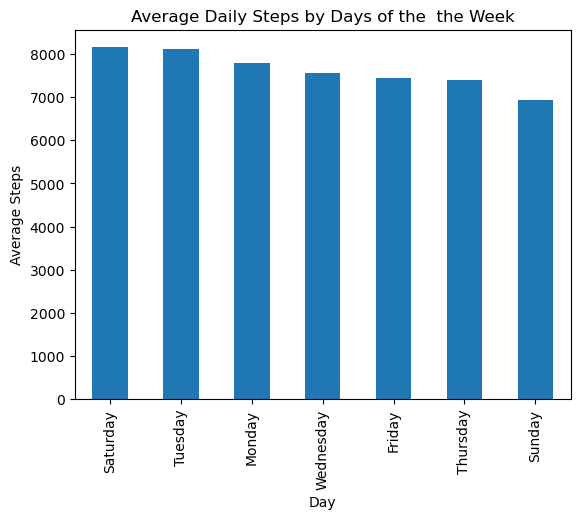

In [23]:
# sort the data from highest to lowest using the .sort_values() method
# plot sorted data
weekday_steps.sort_values(ascending=False).plot(kind='bar')

plt.title('Average Daily Steps by Days of the  the Week')
plt.xlabel('Day')
plt.ylabel('Average Steps')

plt.show()

**Observation**

Users appear to record the highest average step counts during Saturdays which suggests that weekends (Saturdays) may encourage greater physical activity.
The slight decrease on Sunday indicates a reduction in user activities. However, it should be noted that a varying number of factors could have resulted to users having a lower average daily step for Sunday; correlation doesn't mean causation.

#### Distribution of Daily Calories

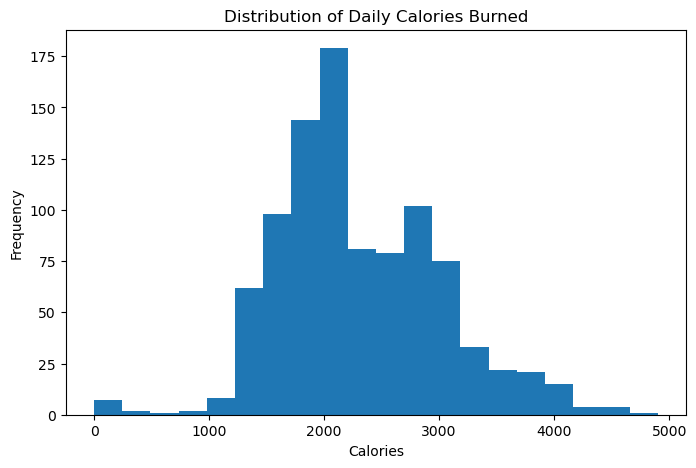

In [90]:
plt.figure(figsize=(8,5))

plt.hist(
    daily_activity['Calories'],
    bins=20
)

plt.title('Distribution of Daily Calories Burned')
plt.xlabel('Calories')
plt.ylabel('Frequency')

plt.show()

#### Calories vs Steps

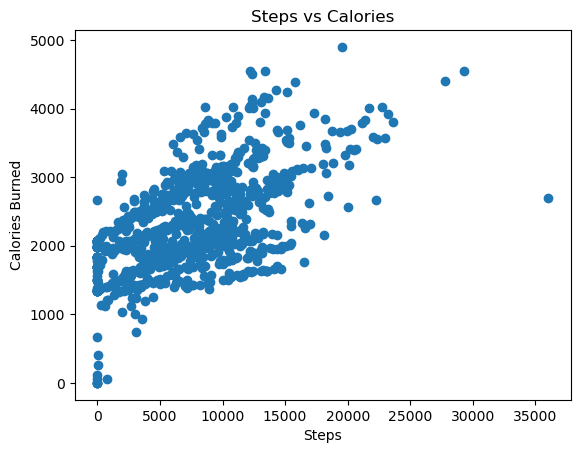

In [44]:
# Showing the relation between the two dataframes:

plt.scatter(
    daily_activity['TotalSteps'],
    daily_activity['Calories']
)

plt.title('Steps vs Calories')
plt.xlabel('Steps')
plt.ylabel('Calories Burned')

plt.show()


**Observation**

The higher the steps increase, the higher the calories that are burned, which suggests having a consistent increase in steps would burn more calories.

#### Active Minutes vs Calories (Scatter Plot)

In [86]:
# Create the total active minutes first.

daily_activity['TotalActiveMinutes'] = (
    daily_activity['VeryActiveMinutes']
    + daily_activity['FairlyActiveMinutes']
    + daily_activity['LightlyActiveMinutes']
)

##### Now plot...

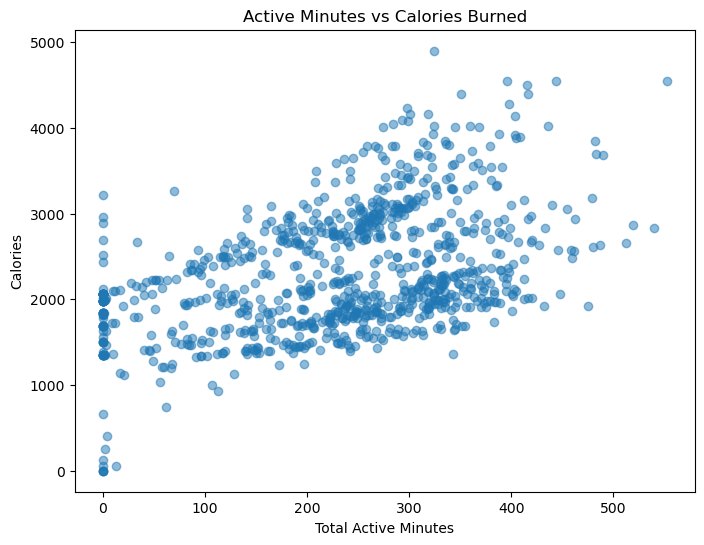

In [87]:
plt.figure(figsize=(8,6))

plt.scatter(
    daily_activity['TotalActiveMinutes'],
    daily_activity['Calories'],
    alpha=0.5
)

plt.title('Active Minutes vs Calories Burned')
plt.xlabel('Total Active Minutes')
plt.ylabel('Calories')

plt.show()

**Observation**

As with the steps, an increase in activities (by minutes) increases the amount of calories burned.

#### Sedentary duration
##### Daily Sedentary Minutes (Bar Chart)

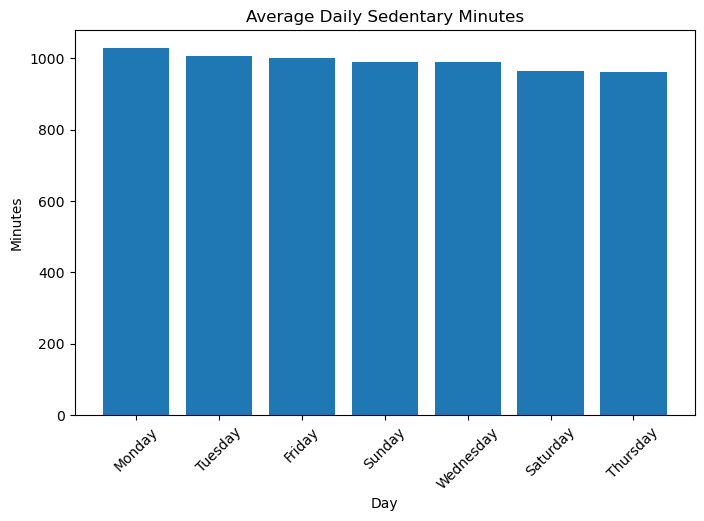

In [35]:
sedentary = (
    daily_activity.groupby('DayOfWeek')['SedentaryMinutes']
    .mean()
    .reindex(weekday_steps.index)
    .sort_values(ascending=False) # to sort the data
)

plt.figure(figsize=(8,5))

plt.bar(
    sedentary.index,
    sedentary.values
)

plt.title('Average Daily Sedentary Minutes')
plt.xlabel('Day')
plt.ylabel('Minutes')

plt.xticks(rotation = 45)

plt.show()

**Observation**

* **Monday** shows the highest average sedentary time, exceeding 1,000 minutes (approximately **16.6 hours**). This strongly aligns with a typical corporate schedule where users return to desks, sit through morning meetings, or spend long stretches answering emails after the weekend.
* Sedentary minutes drop noticeably on **Thursday** and **Saturday**. This suggests that as the week winds down or transitions into the weekend, users naturally engage in more non-sedentary activities (such as errands, social events, or recreational movement).
* As seen, users spend an average of 991 minutes on a daily basis, which suggests approximately that users spend 16 hours having little or no physical activity during the day. Perhaps users in this dataset comprise mostly desk workers or jobs that require little or no physical exertion of energy, just saying though.
* Also, this suggests that users could be spending approximately 7 hours daily on sleep, light, moderate, and vigorous activities.

#### Sedentary Minutes vs. Calories Burned

In [36]:
# merge intensity and calories dfs
sedentary_activity = pd.merge(
    intensity,
    calories,
    on = ['Id', 'ActivityDay'], # Since the column names match in both dataframes
    how = 'inner'
)
sedentary_activity.head()



,Id,ActivityDay,SedentaryMinutes,LightlyActiveMinutes,FairlyActiveMinutes,VeryActiveMinutes,SedentaryActiveDistance,LightActiveDistance,ModeratelyActiveDistance,VeryActiveDistance,Calories
0,1503960366,2016-04-12,728,328,13,25,0.0,6.06,0.55,1.88,1985
1,1503960366,2016-04-13,776,217,19,21,0.0,4.71,0.69,1.57,1797
2,1503960366,2016-04-14,1218,181,11,30,0.0,3.91,0.40,2.44,1776
3,1503960366,2016-04-15,726,209,34,29,0.0,2.83,1.26,2.14,1745
4,1503960366,2016-04-16,773,221,10,36,0.0,5.04,0.41,2.71,1863


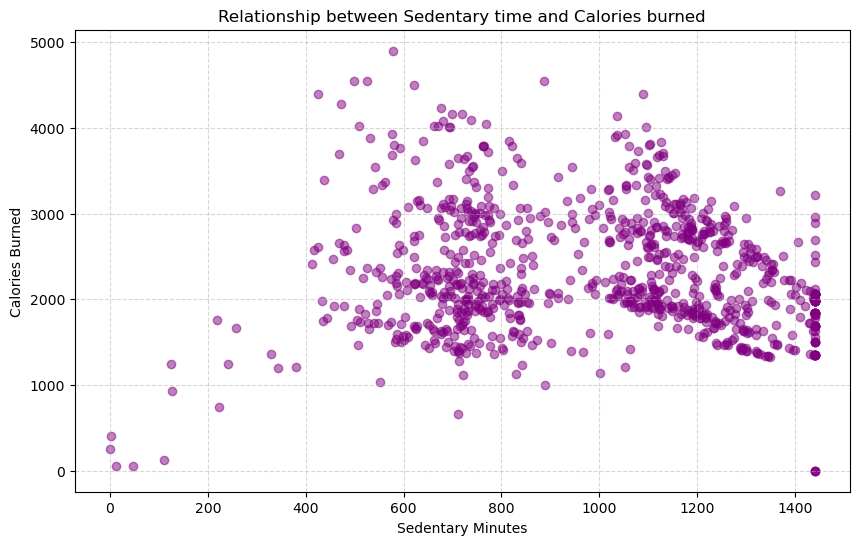

In [39]:
# If there is any relationship between sedentary minutes and calories burned, we plot a scatter plot to find out.
plt.figure(figsize = (10, 6))
plt.scatter(
    sedentary_activity['SedentaryMinutes'],
    sedentary_activity['Calories'],
    alpha = 0.5,
    color = 'purple'
)

plt.title('Relationship between Sedentary time and Calories burned')
plt.xlabel('Sedentary Minutes')
plt.ylabel('Calories Burned')
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.show()

**Observation**
### Interpretation: Sedentary Minutes vs. Calories Burned

An initial look at the scatter plot suggests that there is **no strong linear relationship** between a user's sedentary duration and the total calories they burn. However, a deeper look at the distribution reveals a more nuanced behavioral pattern:

* **The "Active Couch Potato" Phenomenon:** 
  The largest cluster of data sits between **400 and 1,100 sedentary minutes** (approx. 6.5 to 18 hours of inactivity). Within this range, calorie expenditure varies wildly, from under 1,500 to over 4,000 calories. This indicates that a high amount of daily sitting time does not automatically prevent someone from burning a massive amount of calories, likely because they engage in high-intensity workouts outside of their sedentary hours.

* **The Extreme Right Limit (The Ceiling Effect):** 
  A clear downward trend appears once sedentary time exceeds **1,100 minutes** (more than 18 hours). As inactivity approaches 24 hours, the upper limit of calories burned caps out sharply, mostly staying below 2,500 calories. This suggests that while a person can out-train a few hours of sitting, they cannot out-train extreme inactivity; a near-total lack of movement forces calorie expenditure down to baseline levels.

* **The Left-Side Outliers:** 
  The small cluster of points near **0 to 200 sedentary minutes** showing very low calorie expenditure likely represents tracking anomalies (e.g., users who took their smart device off for a significant portion of the day, resulting in under-reported metrics for both categories).

**Summarily:** 
Sedentary duration alone is a poor predictor of daily calorie burn for the average user. It only becomes a strict limiting factor when it dominates nearly the entire 24-hour cycle.

## 3. Relationship Between Activity and Sleep

This section investigates whether users who are more physically active tend to experience better sleep.

In [51]:
# merge the two dataframes, daily_activity and Sleep to a new df

sleep_activity = pd.merge(
    daily_activity, 
    sleep, 
    left_on = ['Id', 'ActivityDate'], 
    right_on = ['Id', 'SleepDay'], 
    how = 'inner'
)

# show dimension of the new df
sleep_activity.shape
# display merged data
sleep_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,DayOfWeek,TotalActiveMinutes,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,13,328,728,1985,Tuesday,366,2016-04-12,1,327,346
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,19,217,776,1797,Wednesday,257,2016-04-13,2,384,407
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,...,34,209,726,1745,Friday,272,2016-04-15,1,412,442
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,...,10,221,773,1863,Saturday,267,2016-04-16,2,340,367
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,...,20,164,539,1728,Sunday,222,2016-04-17,1,700,712


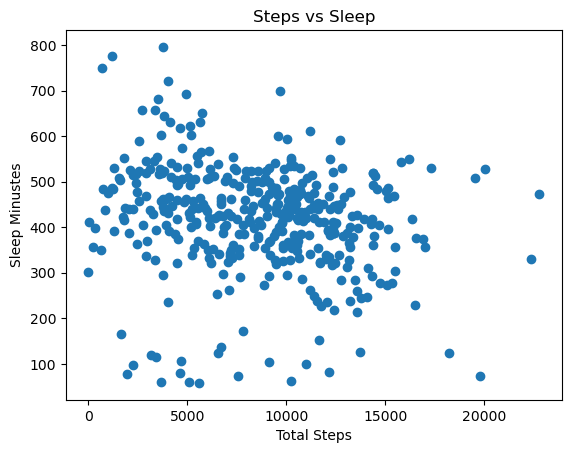

In [52]:
# Using a scattered chat to show the relationship between sleep and daily_activity

plt.scatter(
    sleep_activity['TotalSteps'], 
    sleep_activity['TotalMinutesAsleep']
)

plt.title('Steps vs Sleep')
plt.xlabel('Total Steps')
plt.ylabel('Sleep Minustes')

plt.show()

**Observation**
* **No Strong Linear Correlation:** The data points form a dense, somewhat circular cluster rather than a clear diagonal line, indicating that there is no direct linear relationship between daily step count and total minutes asleep (i.e., taking more steps does not automatically guarantee longer sleep minutes).
* **The "Baseline" Cluster:** The vast majority of observations concentrate between **5,000 and 12,000 steps** and **350 to 550 minutes of sleep** (approximately 6 to 9 hours). This represents the typical daily routine and healthy baseline for most users in the dataset.
* **Variance and Outliers:** 
  * At lower step counts (under 5,000 steps), sleep duration remains highly variable, showing that sedentary days do not inherently prevent a full night's sleep for all individuals.
  * At higher activity levels (above 15,000 steps), sleep duration tends to tighten up towards the 400–500 minute baseline, which suggests that highly active days may help stabilize sleep into a healthy, normal range.

In [57]:
# Using the .corr method to see the correlation matrix in the sleep_activity merged data.
sleep_activity[
    ['TotalSteps',
     'Calories',
     'TotalMinutesAsleep',
     'TotalTimeInBed']
].corr()

,TotalSteps,Calories,TotalMinutesAsleep,TotalTimeInBed
TotalSteps,1.000000,0.411996,-0.186866,-0.164060
Calories,0.411996,1.000000,-0.028526,-0.132507
TotalMinutesAsleep,-0.186866,-0.028526,1.000000,0.930457
TotalTimeInBed,-0.164060,-0.132507,0.930457,1.000000


**Statistical Interpretation** (Correlation Matrix Analysis)
To validate our visual observations, a correlation matrix was calculated for key activity and sleep metrics:

*   **TotalSteps vs. Calories ($0.41$):** Indicates a **moderate positive correlation**. As expected, a higher daily step count linearly relates to increased calorie expenditure.
*   **TotalMinutesAsleep vs. TotalTimeInBed ($0.93$):** Exhibits an **extremely strong positive correlation**. This confirms that the time spent in bed is highly efficient and directly scales with actual sleep duration.
*   **TotalSteps vs. TotalMinutesAsleep ($-0.19$):** Demonstrates a **very weak, negligible negative correlation**. This statistically confirms the scatter plot analysis.
In summary, there is no meaningful linear relationship suggesting that higher daytime activity level (walking) yields longer sleep duration at night.


## 4. Weight Trends

Weight records are available for a limited number of users. Therefore, this analysis is supplementary and should not be generalized to the entire population.

In [79]:
# merging both daily_activity and weight dfs

weight_activity = pd.merge(
    daily_activity,
    weight,
    left_on = ['Id', 'ActivityDate'],
    right_on = ['Id', 'Date'],
    how = 'inner'
)

# display weight_activity
weight_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,Calories,DayOfWeek,TotalActiveMinutes,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,2016-05-02,14727,9.71,9.71,0.0,3.21,0.57,5.92,0.00,...,2004,Monday,333,2016-05-02,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,2016-05-03,15103,9.66,9.66,0.0,3.73,1.05,4.88,0.00,...,1990,Tuesday,328,2016-05-03,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,2016-04-13,356,0.25,0.25,0.0,0.00,0.00,0.25,0.00,...,2151,Wednesday,32,2016-04-13,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,2016-04-21,8859,5.98,5.98,0.0,0.13,0.37,5.47,0.01,...,1970,Thursday,383,2016-04-21,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,2016-05-12,7566,5.11,5.11,0.0,0.00,0.00,5.11,0.00,...,1431,Thursday,268,2016-05-12,57.299999,126.324875,NaN,21.690001,True,1463097599000


#### Number of weight logs

In [80]:
weight['WeightKg'].describe()

count     67.000000
mean      72.035821
std       13.923206
min       52.599998
25%       61.400002
50%       62.500000
75%       85.049999
max      133.500000
Name: WeightKg, dtype: float64

In [81]:
weight['BMI'].describe()

count    67.000000
mean     25.185224
std       3.066963
min      21.450001
25%      23.959999
50%      24.389999
75%      25.559999
max      47.540001
Name: BMI, dtype: float64

**Observation**

The UN Body Mass Index (BMI) for adults is between *18.5* and *24.9*, and our data shows an average BMI of approximately **25**, which suggests users are slightly above the standard BMI ratio. However, because only a small proportion of users consistently logged their weight, these findings should be interpreted with caution.

### Correlation Heatmap
A heatmap showing the correlation between TotalSteps, Calories, VeryActiveMinutes, FairlyActiveMinutes, LightlyActiveMinutes, and SedentaryMinutes.

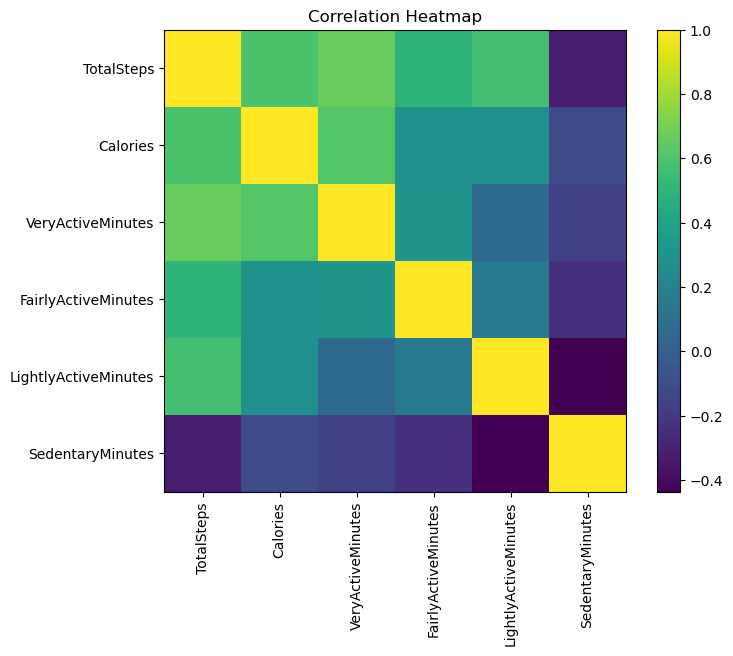

In [99]:


correlation = daily_activity[
    [
        'TotalSteps',
        'Calories',
        'VeryActiveMinutes',
        'FairlyActiveMinutes',
        'LightlyActiveMinutes',
        'SedentaryMinutes'
    ]
].corr()

plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

**Observation**

The correlation heatmap generated reveals several important relationships between user activity metrics and caloric burn:

*   **Strong Positive Correlation ($r \approx 1.0$): `TotalSteps` & `Calories`**
    *   There is a clear, strong positive correlation between the total steps taken and calories burned. This aligns with standard expectations that higher physical movement directly influences energy expenditure.
    *   *Note:* The diagonal line from top-left to bottom-right shows perfect correlation ($1.0$) because it compares each variable against itself.

*   **Impact of Activity Intensity: `VeryActiveMinutes` vs. `LightlyActiveMinutes`**
    *   `VeryActiveMinutes` displays a significantly stronger positive correlation with `Calories` compared to `LightlyActiveMinutes` or `FairlyActiveMinutes`. 
    *   **Insight:** The *intensity* of the activity is a much stronger driver of caloric burn than duration alone. 

*   **Step Count as a Baseline Proxy**
    *   `TotalSteps` has a solid, moderate-to-high positive correlation across all active categories (`VeryActiveMinutes`, `FairlyActiveMinutes`, and `LightlyActiveMinutes`). This confirms that tracking step count serves as an effective baseline metric for overall daily activity levels.

*   **Negative Correlation: `SedentaryMinutes`**
    *   `SedentaryMinutes` shows an inverse (negative) relationship with all other active metrics and `Calories` (indicated by the darker purple blocks). 
    *   **Insight:** Increased stationary time directly corresponds to fewer steps taken and lower overall daily caloric burn.


## Business Insights

| Question                          | Analysis                        | Possible Insight                                                                                       |
| --------------------------------- | ------------------------------- | ------------------------------------------------------------------------------------------------------ |
| How active are users?             | Average daily steps             | Users' average daily steps is fewer than the commonly recommended 10,000 steps.                                        |
| Which days are users most active? | Bar chart of Average Daily Steps by Days of the week | Activity is highest on weekends (Saturdays especially).                              |
| Does more activity mean more calories burned? | Scatter plot of Steps vs. Calories | Higher activity results in an increase in calories that are burned. |
| Does activity relate to sleep?    | Scatter plot of steps vs. sleep | The relationship appears weak, suggesting sleep duration depends on more than physical activity alone. |
| Are users sedentary?              | Sedentary duration                | High sedentary time indicates an opportunity for Bellabeat to encourage regular movement among users.              |
| Which days are users most sedentary? | Bar chart of Sedentary minutes | Every day except for Thursdays and Saturdays are more sedentary for users with Monday being at the peak. |
| Is weight data representative?    | Number of weight logs           | Weight logging is infrequent, so conclusions should be treated cautiously.                             |


## Key Insights for Bellabeat's Marketing Strategy:
* **Automation is King**: Features that require zero user effort (Steps, Calories, Intensity) have 100% participation (33/33 users). Users rely on the device to passively collect their daily movement.

* **The "Friction" Drop-off (Sleep)**: Sleep tracking requires wearing the device to bed consistently. We see a drop down to 24 users, indicating that a segment of consumers finds wearing a tracker to sleep uncomfortable or forgets to charge/wear it at night.

* **The Manual Entry Barrier (Weight)**: Weight tracking has an abysmal 8-user participation rate. Because this requires manual logging (or an expensive smart scale ecosystem), users almost completely ignore it.



#### **Recommendation for Bellabeat:**
1. Given that Monday is the most stationary day of the week, Bellabeat could implement **targeted notification reminders** specifically on Monday mornings and early afternoons. Prompting users to stand up, stretch, or take a short walk during this high-sedentary peak would offer a high-impact opportunity to improve user wellness (burning up more calories).
2. Implement gentle, personalized notifications prompting users to move or stretch if the device detects prolonged periods of `SedentaryMinutes`.
3. Encourage users to log even short bursts of high-intensity workouts (`VeryActiveMinutes`), emphasizing efficiency in reaching fitness and caloric goals over long, low-intensity sessions.

# Recommendations for Bellabeat

Based on the patterns uncovered in the Fitbit user data, Bellabeat can optimize its app features and marketing strategies by focusing on the following areas:

1. **Targeted Monday Reminders (Combating Sedentary Peaks)**
   * **Insight:** Monday stands out as the day with the highest potential for sedentary behavior and lower relative activity. 
   * **Action:** Implement personalized, encouraging push notifications on Monday mornings and early afternoons (e.g., *"Let's conquer the week! Time for a quick 5-minute stretch"*). Prompting users to break up stagnant periods early in the week offers a high-impact opportunity to improve overall wellness.


2. **Incentivize High-Intensity, Efficient Workouts**
   * **Insight:** The data shows that `VeryActiveMinutes` has a significantly stronger correlation with caloric burn than lower-intensity tracking. 
   * **Action:** Market the Bellabeat app/leaf as a tool for *efficient* fitness. Introduce short, high-intensity interval training (HIIT) guides in the app and encourage users to log even 10–15 minutes of vigorous activity, emphasizing a high return on investment for their busy schedules.

3. **Smart Sedentary Alerts**
   * **Insight:** There is a clear, consistent negative correlation between sedentary time and health metrics (steps, calories, active minutes). 
   * **Action:** Build a customizable "Inactivity Alert" feature. If the Bellabeat tracker detects zero active movement for a prolonged period (e.g., 2 hours during work hours), gently nudge the user to stand up, hydrate, or take a short walk.

4. **Capitalize on Weekend Momentum**
   * **Insight:** Users consistently record their highest average step counts on Saturdays, showing a natural inclination to move when they have free time.
   * **Action:** Launch weekend community challenges or streaks within the Bellabeat app (e.g., "Saturday Step-Up") to gamify and celebrate this existing behavioral peak.


# Conclusion

This analysis of smart device trends highlights a critical opportunity for Bellabeat to position itself not just as a passive data tracker but as an **active wellness partner**.
Bellabeat should lean heavily into marketing its passive, automatic tracking capabilities (like seamless, comfortable sleep tracking designed specifically for women's lifestyle habits) and find gamified or automated ways to reduce the friction of manual data logs like hydration or weight.

The data indicates that regular movement and intensive activity are the primary drivers of caloric expenditure, while prolonged stationary time (being more sedentary) predictably hinders health goals. By leveraging these insights—specifically by prompting action during sedentary valleys (Mondays) and celebrating activity peaks (Saturdays)—Bellabeat can design a highly tailored wellness app that empowers user experience. This will ultimately guide users to balance intensity and movement throughout their busy weeks and solidify Bellabeat's footprint in the global smart wellness market.